In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json
import pandas as pd
from skimage.segmentation import watershed

from tqdm import tqdm

from GDRT.raster_point.raster_point import find_best_shift, corr_nan_weighted_func, WMAE

In [2]:
FIELD_TREES_FOLDER = "/ofo-share/scratch/david/species-tree-detection-eval/data/manual_shifts_filtered"
CHMS_FOLDER = "/ofo-share/project-data/species-prediction-project/intermediate/CHMs"
SHIFT_QUALITY_FILE = "/ofo-share/project-data/species-prediction-project/intermediate/shift_quality.csv"

In [3]:
shift_qualities = pd.read_csv(SHIFT_QUALITY_FILE)
high_quality_datasets = shift_qualities[shift_qualities["Quality"] > 2].Dataset.values
high_quality_datasets = [d.split(".")[0] for d in high_quality_datasets]

0it [00:00, ?it/s]

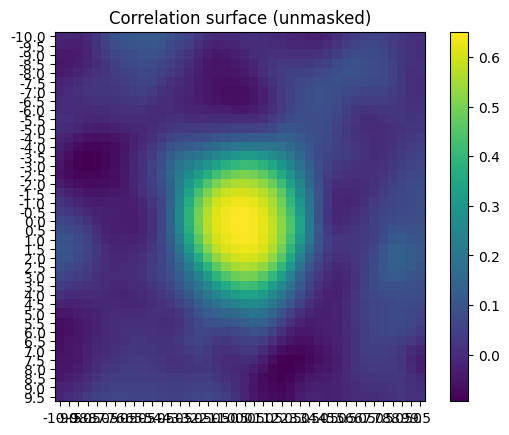

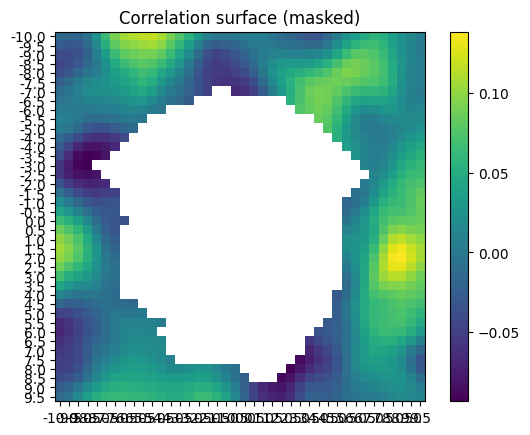

25it [01:41,  3.30s/it]

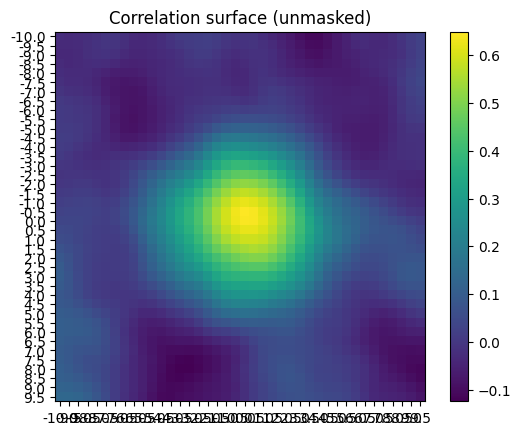

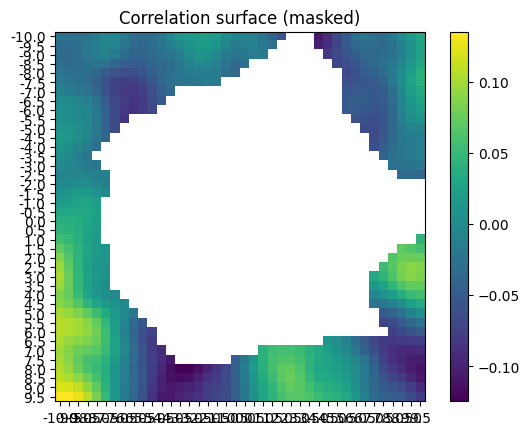

27it [01:56,  5.00s/it]/home/exouser/miniconda3/envs/GDRT-dev/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/exouser/miniconda3/envs/GDRT-dev/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
50it [03:27,  4.12s/it]

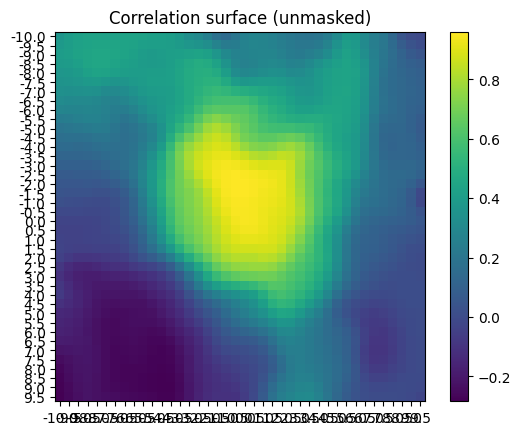

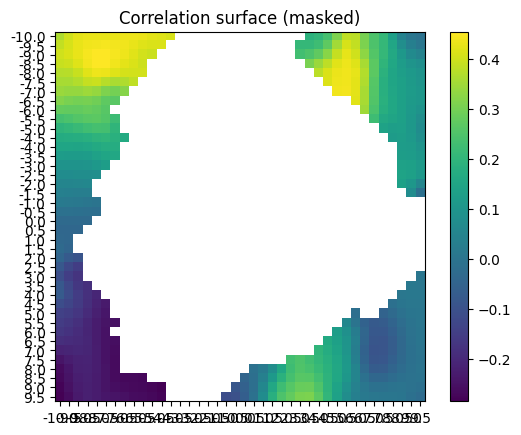

60it [03:59,  2.91s/it]/home/exouser/miniconda3/envs/GDRT-dev/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/exouser/miniconda3/envs/GDRT-dev/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/ofo-share/repos/david/geospatial-data-registration-toolkit/GDRT/raster_point/raster_point.py:169: RuntimeWarning: All-NaN slice encountered
  secondary_max = np.nanmax(img_copy)
75it [05:52, 14.65s/it]

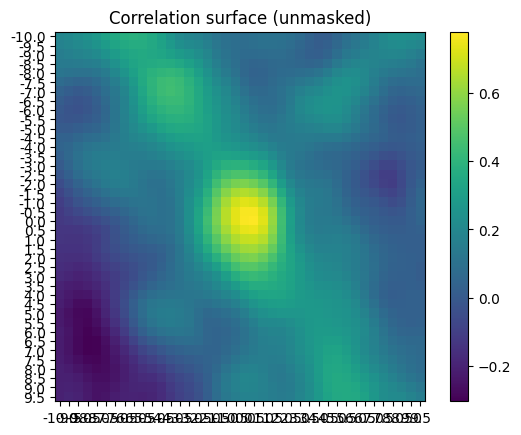

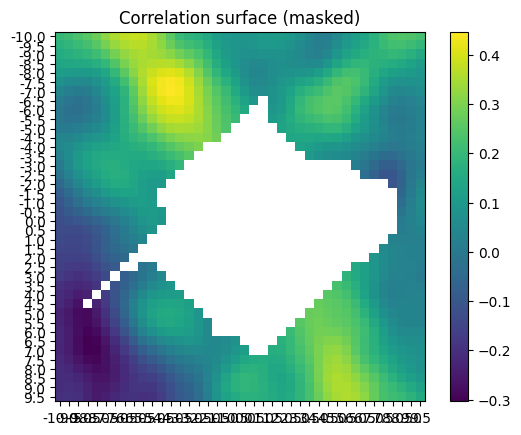

100it [08:41,  6.88s/it]

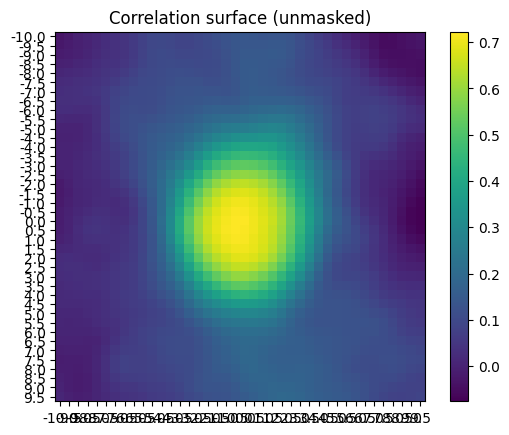

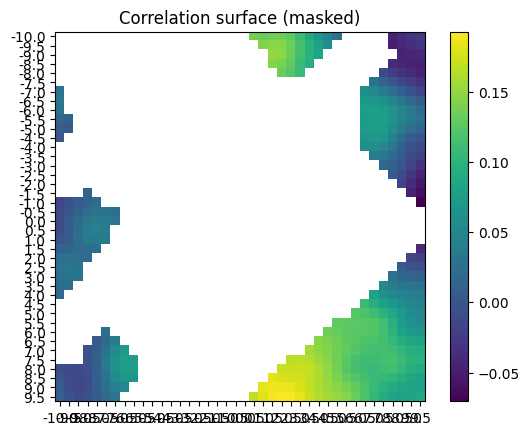

108it [10:29,  9.19s/it]/home/exouser/miniconda3/envs/GDRT-dev/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/exouser/miniconda3/envs/GDRT-dev/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
119it [12:19,  6.85s/it]/home/exouser/miniconda3/envs/GDRT-dev/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/exouser/miniconda3/envs/GDRT-dev/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
125it [12:35,  3.62s/it]

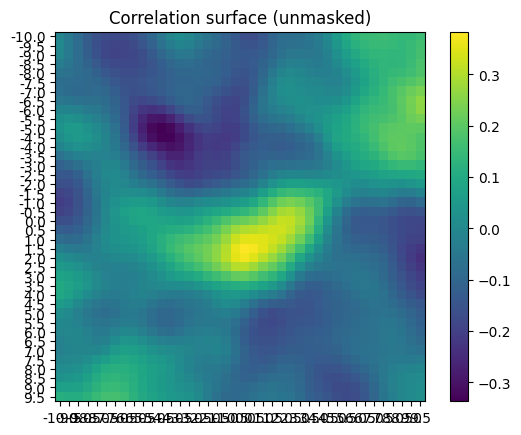

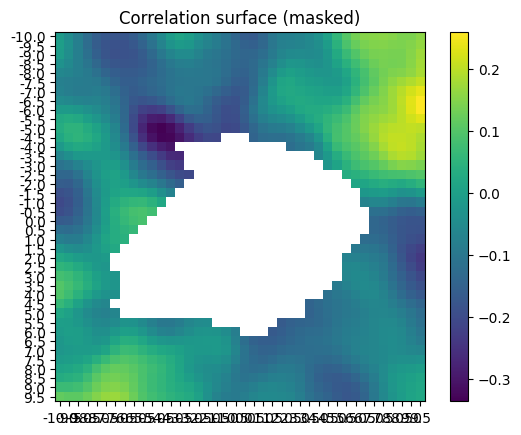

150it [15:39, 10.00s/it]

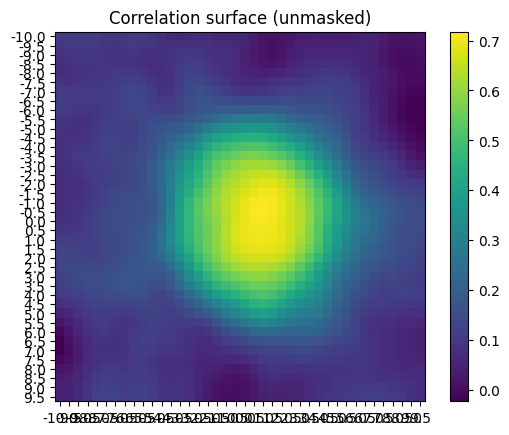

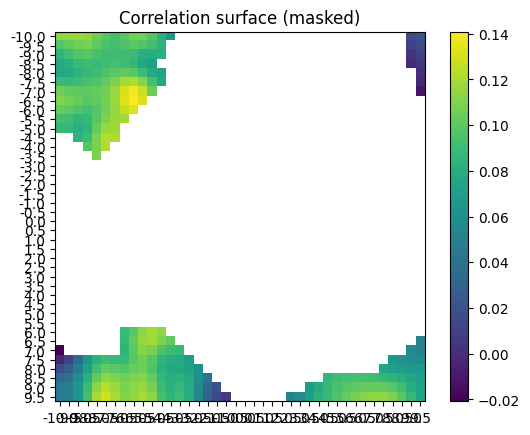

158it [16:16,  6.18s/it]


In [4]:
CHM_files = Path(CHMS_FOLDER).glob("*.tif")
CHM_datasets = [f.stem for f in CHM_files]
matching_datasets = set(list((high_quality_datasets))).intersection(CHM_datasets)

best_shifts = []
ratios = []

for i, dataset in tqdm(enumerate(matching_datasets)):
    field_tree = Path(FIELD_TREES_FOLDER, f"dataset_{dataset}.gpkg")
    CHM = Path(CHMS_FOLDER, f"{dataset}.tif")

    result = find_best_shift(
        raster_file=CHM,
        points_file=field_tree,
        x_range=(-10, 10, 0.5),
        y_range=(-10, 10, 0.5),
        vis=(i % 25 == 0),
    )

    best_shifts.append(result["best_shift"])
    ratios.append(result["ratio"])

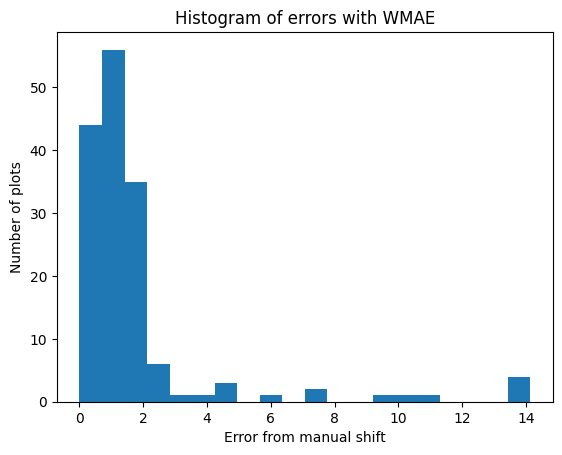

In [8]:
best_shifts_array = np.array(best_shifts)
dists = np.linalg.norm(best_shifts_array, axis=1)
plt.title("Histogram of errors with WMAE")
plt.xlabel("Error from manual shift")
plt.ylabel("Number of plots")
plt.hist(dists, bins=20)
plt.show()

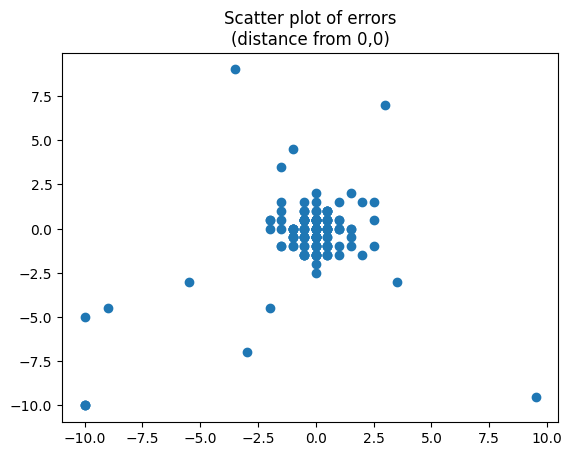

In [13]:
plt.show()
plt.scatter(
    best_shifts_array[:, 0],
    best_shifts_array[:, 1],
)
plt.title("Scatter plot of errors\n(distance from 0,0)")
plt.show()

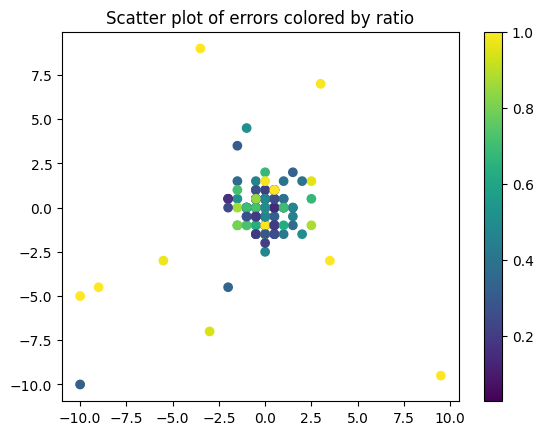

In [15]:
plt.show()
plt.scatter(
    best_shifts_array[:, 0],
    best_shifts_array[:, 1],
    c=ratios,
    cmap="viridis",
)
plt.title("Scatter plot of errors colored by ratio")
plt.colorbar()
plt.show()

Text(0, 0.5, 'Errors')

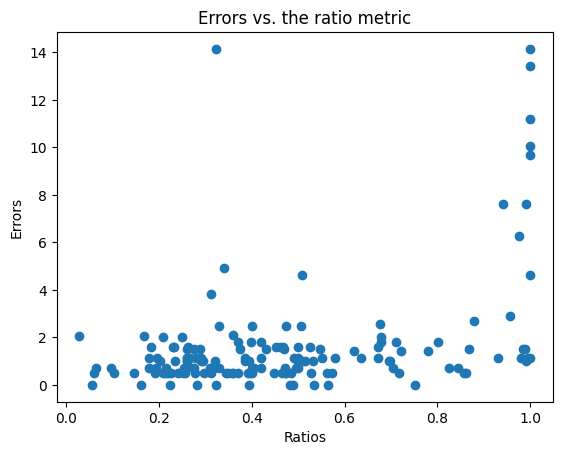

In [16]:
plt.scatter(ratios, dists)
plt.title("Errors vs. the ratio metric")
plt.xlabel("Ratios")
plt.ylabel("Errors")